### Imports

In [1]:
# Imports
import torch
import os
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
import sys
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM
# some additional functions
import SIGSOM.sigsom.utils.helpers2 as helper_functions

In [2]:
raw_data1 = st.load_pbz2(r"..\SIGSOM\sigsom\data\crypro_ohlcv_data\hdp_rest_PERPETUAL_BINANCE_PERPETUAL_ADA-USDT_20220101_20231006.pbz2")


raw_data1['datetime']= raw_data1.index
raw_data1['datetime'] = raw_data1['datetime'].dt.tz_localize(None)

# Perform resampling on the loaded data
start_date = '2022-01-01'  # Define start date

# Resample the data
resampled_data1 = helper_functions.resample_data(raw_data1, resample_rule='5T', start_date=start_date, price_column='close', volume_column='volume')

resampled_data1 = resampled_data1[:185018*100]

# Check Shapes
print(resampled_data1.shape)


# Normalize and window

data_5min_1 = resampled_data1.values 
data_5min_1 = torch.tensor(data_5min_1, dtype=torch.float32) 
data_5min_1 = st.rolling_window1(data_5min_1, window=96*10) # from 96*5
data_5min_1 = data_5min_1 - data_5min_1[:,0:1]
data_5min_1 /= torch.std(data_5min_1, dim=1, keepdim=True)

# Concatenate
multivariate_path=torch.cat([data_5min_1[:]], dim=2)
multivariate_path.shape

# Split into training and test sets
train_data = multivariate_path[:100]
test_data = multivariate_path[100:]

# Compute Min-Max scaling only on the training set
data_min = train_data.min(dim=0, keepdim=True)[0].min(dim=1, keepdim=True)[0]
data_max = train_data.max(dim=0, keepdim=True)[0].max(dim=1, keepdim=True)[0]

# Apply Min-Max scaling using training statistics
train_scaled = (train_data - data_min) / (data_max - data_min)
test_scaled = (test_data - data_min) / (data_max - data_min)  # Use train min/max!

# Check the range of the scaled data
print(train_scaled.min().item(), train_scaled.max().item())  # Should be ~0 to 1
print(test_scaled.min().item(), test_scaled.max().item())    # May have some out-of-range values

# Combine back for later use if needed
scaled_data = torch.cat([train_scaled, test_scaled], dim=0)

print(scaled_data.shape)


(185018, 2)
0.0 1.0
-0.0293844323605299 1.1802581548690796
torch.Size([192, 960, 2])


In [3]:
import torch
import math
from sympy import mobius, divisors

# Augmentations
augmentations = [
    (st.lead_lag_transform, {}),
]

# Transforms
transforms = [(st.log_singature, {"depth": 3, "basepoint": False})]

# Pipeline function
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)  # Apply augmentation
        # print("aug",np.isnan(aug).any())
        for trans, trans_kwargs in transforms:
            sig = trans(aug, **trans_kwargs)  # Apply transformation (e.g., log signature)
            # print("signature",np.isnan(sig).any())
            # Rescale the signature terms by depth factorial on the feature dimension (not the batch)
            depth = trans_kwargs["depth"]
            dimension = aug.shape[2]  # Number of input dimensions (e.g., 6)
            rescaled_sig = st.rescale_signature_by_factorial("log", sig, dimension, depth)

            # Generate key for storing results
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = rescaled_sig

    return results

# Example usage with multivariate path (6-dimensional tensor)
# Assuming multivariate_path is a tensor of shape [8000, 6]

# Apply the pipeline
results1 = apply_pipeline(scaled_data[:], augmentations, transforms)

# Print the shape of the rescaled signature output
print(results1["lead_lag_transform_log_singature"].shape)


torch.Size([192, 30])


# Save Signatures for Autoencoding

In [4]:
vif_cleaned_result = st.remove_vif(results1["lead_lag_transform_log_singature"], threshold=4)
vif_cleaned_result.shape

torch.Size([192, 8])

### FITTING SOM

In [5]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
# from GSOMM3 import GSOMM

# Initializing variables to store the best model and the lowest quantization error
best_gsomm = None
lowest_quantization_error = float('inf')

# Perform the process 20 times
for i in range(30):
    print(f"Run {i+1}/20")

    # Preprocess the data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)

    train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)

    # Set SOM parameters
    params = SOMParams(map_size=(2, 1),Tmax=6,Tmin=.01,batch_size = 512,iterations = 500, input_dims=train_matrix1.shape[1], lr=0.05, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))


    gsomm = GSOMM(logger=logger, params=params)
    gsomm.somm.initialize(train_matrix1)

    # Train the SOM and calculate quantization error
    inital_preds2, initial_quantization_error = gsomm.initial_train(X_train=train_matrix1)

    # Compare the quantization error to find the best model
    if initial_quantization_error < lowest_quantization_error:
        lowest_quantization_error = initial_quantization_error
        best_gsomm = gsomm
        print(f"New best model found with quantization error: {initial_quantization_error.item()}")

# Output the lowest quantization error and the best model
print(f"Lowest quantization error: {lowest_quantization_error.item()}")


2025-02-24 11:44:29,476     adapted_som INFO     MainThread   MainProcess Training Initial SOMM
2025-02-24 11:44:29,478     adapted_som INFO     MainThread   MainProcess Save interval: 50


Run 1/20
updated
tensor(7.8262)


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\torch\_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values.
To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor'). (Triggered internally at  ..\aten\src\ATen\native\BinaryOps.cpp:467.)
  return torch.floor_divide(self, other)
2025-02-24 11:44:29,666     adapted_som INFO     MainThread   MainProcess Iteration 49 - T=N/A
2025-02-24 11:44:29,670     adapted_som INFO     MainThread   MainProcess   [Train] - L = 15.106, L_km = 7.826000213623047
2025-02-24 11:44:29,674     adapted_som INFO     MainThread   MainProcess   [Train] - L = 15.106, som_loss = 15.105999946594238


2025-02-24 11:44:32,322     adapted_som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-24 11:44:32,337     adapted_som INFO     MainThread   MainProcess   [Train] - L = 13.464, L_km = 7.692999839782715
2025-02-24 11:44:32,337     adapted_som INFO     MainThread   MainProcess   [Train] - L = 13.464, som_loss = 13.46399974822998


tensor(7.6930)


...

tensor(7.1796)


2025-02-24 11:46:20,121     adapted_som INFO     MainThread   MainProcess Iteration 449 - T=N/A
2025-02-24 11:46:20,121     adapted_som INFO     MainThread   MainProcess   [Train] - L = 7.18, L_km = 7.179999828338623
2025-02-24 11:46:20,121     adapted_som INFO     MainThread   MainProcess   [Train] - L = 7.18, som_loss = 7.179999828338623


tensor(7.1796)


2025-02-24 11:46:20,536     adapted_som INFO     MainThread   MainProcess Iteration 499 - T=N/A
2025-02-24 11:46:20,538     adapted_som INFO     MainThread   MainProcess   [Train] - L = 7.18, L_km = 7.179999828338623
2025-02-24 11:46:20,539     adapted_som INFO     MainThread   MainProcess   [Train] - L = 7.18, som_loss = 7.179999828338623


tensor(7.1796)
Lowest quantization error: 714.3773803710938


### Initial Plot not done nicley but its quick

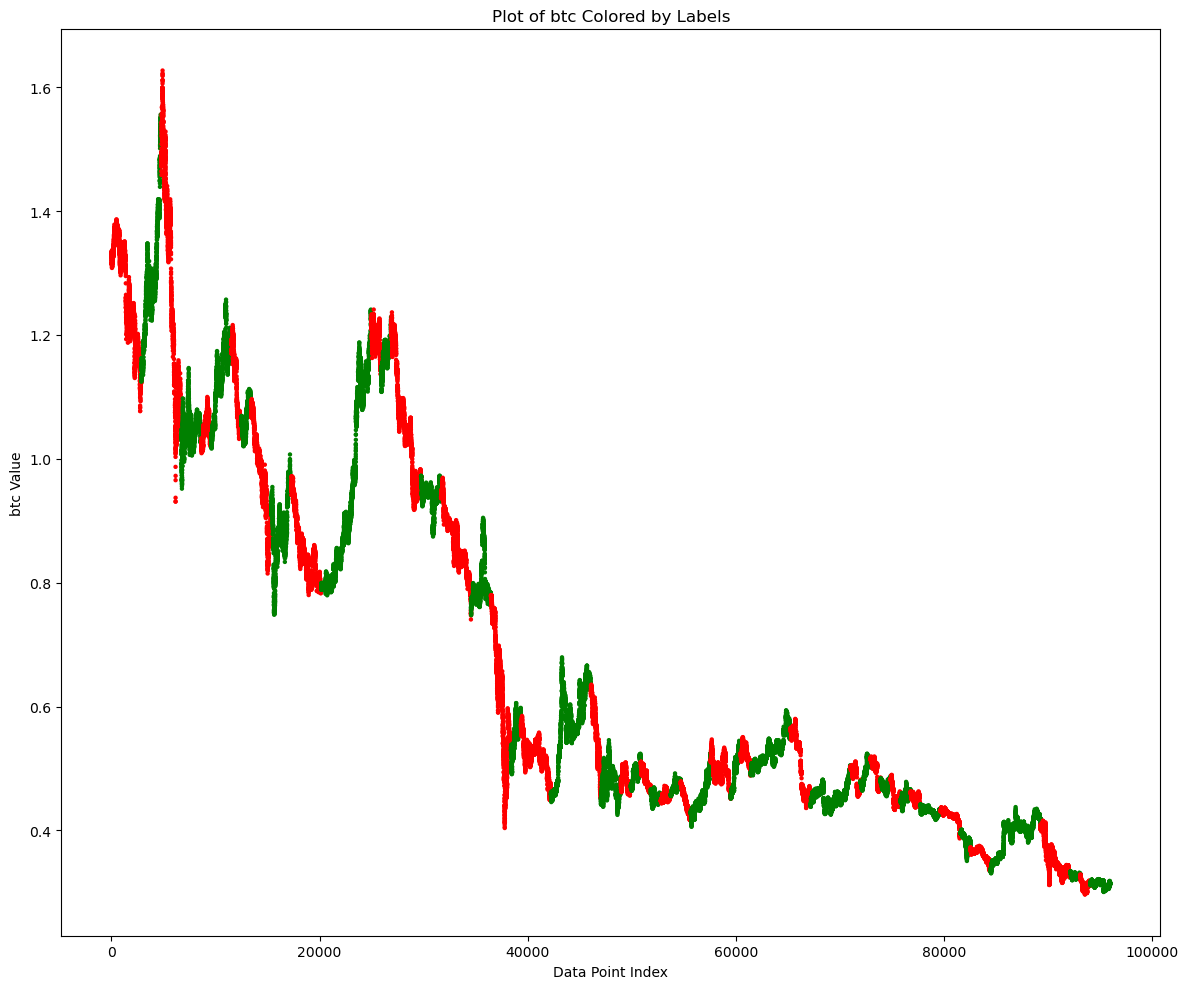

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a,qe,_ = best_gsomm.predict(train_matrix1)

initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)

# # Assuming initial_preds_rep is already defined and repeated correctly
# initial_preds_rep = np.repeat(inital_preds2.cpu(), 10*96)

resampled_data1
# Assuming eth and btc data are already extracted
btc = resampled_data1.values[:96000, 0]


# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs.scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs.set_title('Plot of btc Colored by Labels')
axs.set_xlabel('Data Point Index')
axs.set_ylabel('btc Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


### HMM gaussian

### Nice Plot on the Test Data SOM

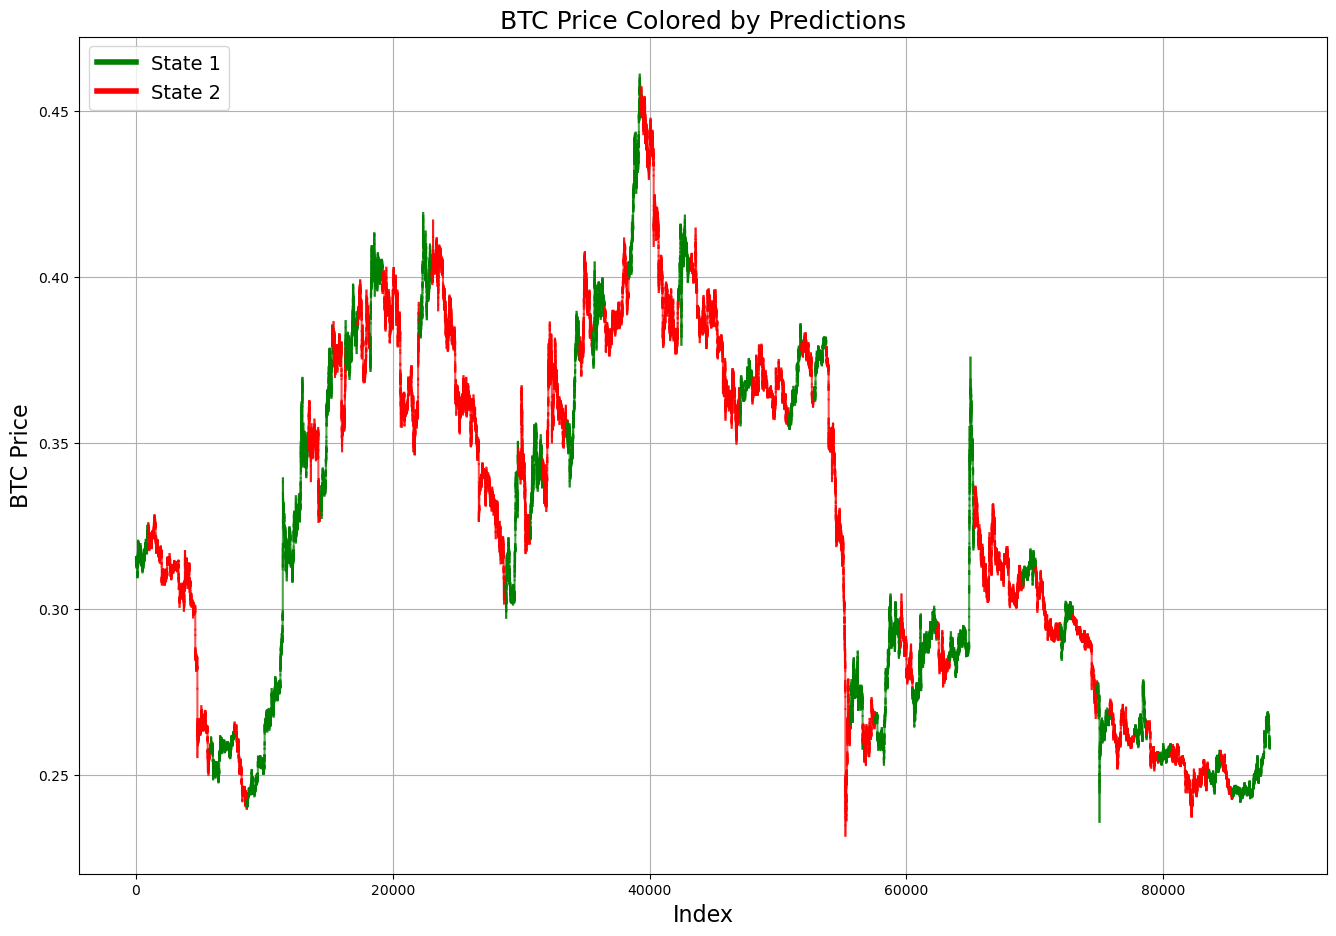

In [7]:
import SIGSOM.sigsom.utils.helpers2 as helper_functions

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
# Assuming `vif_cleaned_result`, scalers, and gsomm are defined elsewhere in the code
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
test_preds, qe, proto = best_gsomm.predict(test_matrix)  # Replace 'gsomm.predict' with your method
test_preds = np.array(test_preds).flatten()
initial_preds_rep = np.repeat(test_preds, 10*96)
initial_preds_rep.shape

# Assuming btc data is already extracted
btc = resampled_data1.values[96000:, 0]
output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\bitcoin.png"

helper_functions.plot_btc_price(predictions=initial_preds_rep, btc_prices=btc, output_path=output_path, title='BTC Price Colored by Predictions')

# Nice Plot of the test data but using the HMM

### HMM FIT

In [8]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
import numpy as np
from hmmlearn import hmm

# Initializing variables to store the best model and the highest log-likelihood
best_hmm = None
best_log_likelihood = -float('inf')

# Number of hidden states (clusters) for the HMM
n_components = 2  # Adjust based on your problem

# Perform the process 20 times
for i in range(20):
    print(f"Run {i+1}/20")

    # Preprocess the data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100, :])  # Ensure vif_cleaned_result is defined

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)

    train_matrix1 = torch.tensor(train_matrix, dtype=torch.float32).numpy()  # Convert to NumPy

    # Fit the HMM
    model = hmm.GaussianHMM(n_components=n_components, covariance_type="diag", n_iter=600, random_state=i)
    model.fit(train_matrix1)  # Train the HMM

    # Compute log-likelihood on training data
    log_likelihood = model.score(train_matrix1)

    # Compare log-likelihood to find the best model
    if log_likelihood > best_log_likelihood:
        best_log_likelihood = log_likelihood
        best_hmm = model
        print(f"New best model found with log-likelihood: {log_likelihood}")

# Output the highest log-likelihood and the best model
print(f"Best log-likelihood: {best_log_likelihood}")


Run 1/20


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



New best model found with log-likelihood: -243.04976242496258
Run 2/20


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



New best model found with log-likelihood: -193.33227863053315
Run 3/20


...

Run 5/20


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



Run 6/20


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



KeyboardInterrupt: 

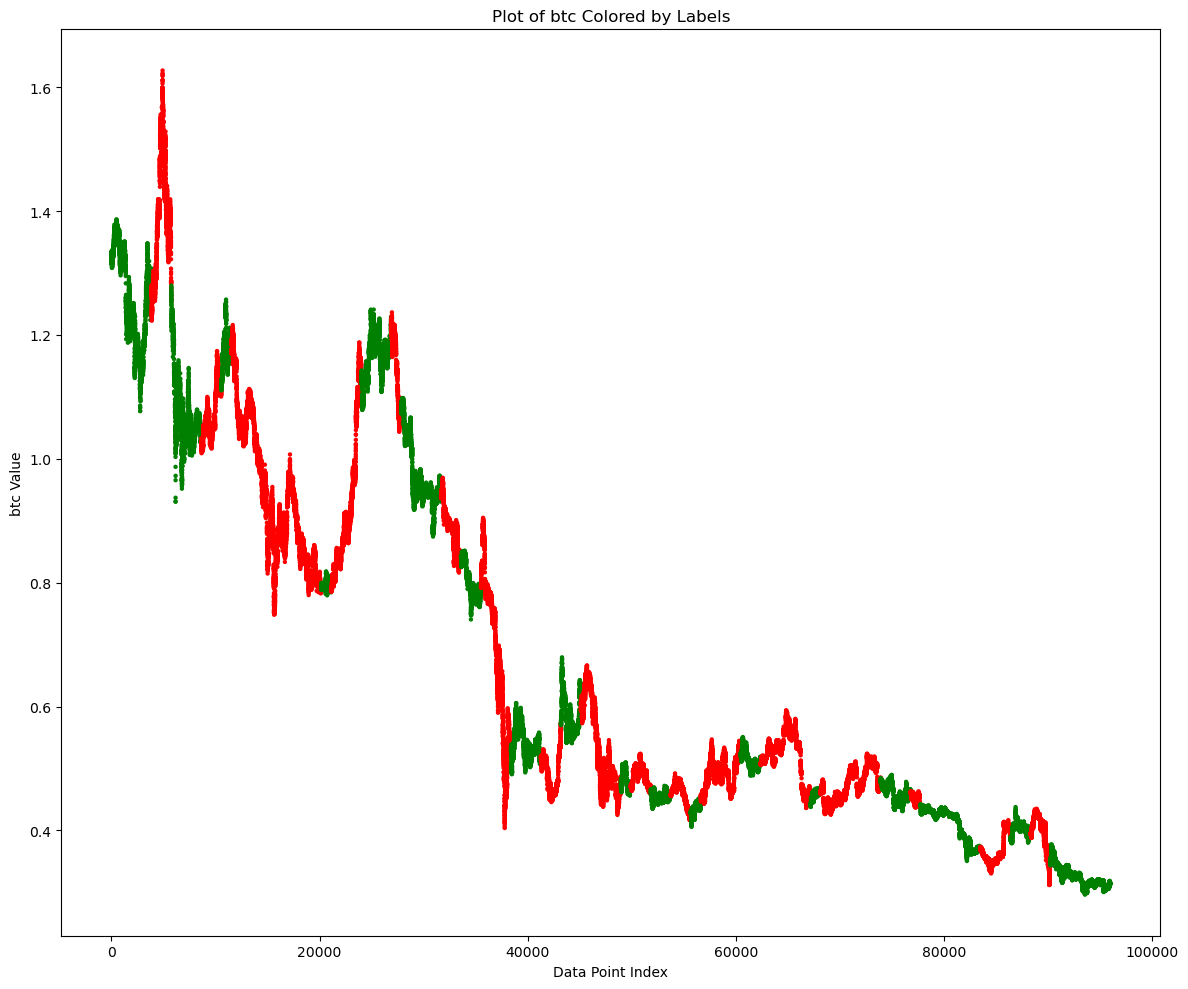

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = best_hmm.predict(train_matrix1)

initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)

# # Assuming initial_preds_rep is already defined and repeated correctly
# initial_preds_rep = np.repeat(inital_preds2.cpu(), 10*96)

resampled_data1
# Assuming eth and btc data are already extracted
btc = resampled_data1.values[:96000, 0]


# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs.scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs.set_title('Plot of btc Colored by Labels')
axs.set_xlabel('Data Point Index')
axs.set_ylabel('btc Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


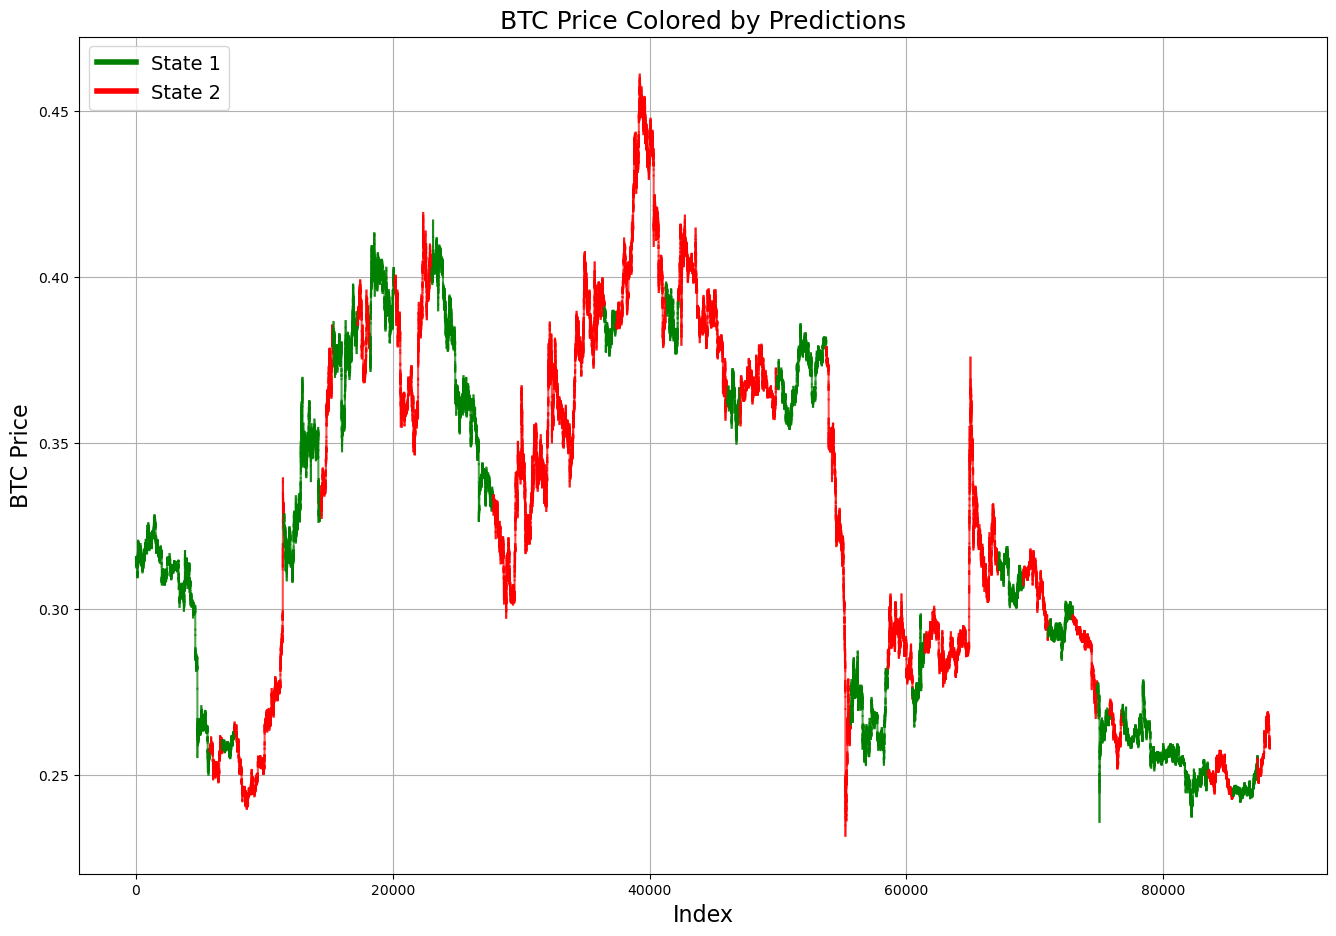

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
# Assuming `vif_cleaned_result`, scalers, and gsomm are defined elsewhere in the code
scaler = PowerTransformer(method='yeo-johnson', standardize=True)
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Get the hidden states from the trained HMM
hmm_preds = best_hmm.predict(test_matrix)  # HMM assigns each time point a hidden state

# Repeat each predicted state to match BTC's time resolution
hmm_preds_rep = np.repeat(np.array(hmm_preds).flatten(), 10*96)

# Extract BTC prices
btc_prices = resampled_data1.values[96000:, 0]  # Assuming BTC data is extracted

helper_functions.plot_btc_price(predictions=hmm_preds_rep, btc_prices=btc_prices, output_path=output_path, title='BTC Price Colored by Predictions')


### Jump Model

# Jump Models
- requires return series as an input
- we will use the raw bitocin data for this and preprocess it according to jump models code and than caluclate the jump model
    

In [ ]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from jumpmodels.jumpmodels.utils import filter_date_range        # useful helpers
from jumpmodels.jumpmodels.jump import JumpModel                 # class of JM & CJM
from jumpmodels.jumpmodels.sparse_jump import SparseJumpModel 

### Get data and resample

In [ ]:
raw_data1 = st.load_pbz2(r"..\SIGSOM\sigsom\data\crypro_ohlcv_data\hdp_rest_PERPETUAL_BINANCE_PERPETUAL_ADA-USDT_20220101_20231006.pbz2")


raw_data1['datetime']= raw_data1.index
raw_data1['datetime'] = raw_data1['datetime'].dt.tz_localize(None)

# Perform resampling on the loaded data
start_date = '2022-01-01'  # Define start date

# Resample the data
resampled_data1 = helper_functions.resample_data(raw_data1, resample_rule='5T', start_date=start_date, price_column='close', volume_column='volume')

resampled_data1 = resampled_data1[:185018*100]


### Get return series

In [ ]:
resampled_data1_returns = resampled_data1.pct_change().iloc[1:,0]
resampled_data1_returns.head()

datetime
2022-01-01 00:05:00    0.000913
2022-01-01 00:10:00    0.001064
2022-01-01 00:15:00   -0.000608
2022-01-01 00:20:00    0.004027
2022-01-01 00:25:00   -0.001514
Freq: 5T, Name: close, dtype: float64

In [ ]:
from jumpmodels.examples.nasdaq.feature import DataLoader
data = DataLoader(ticker="resampled_data1_returns copy", ver="v0").load(start_date="2007-1-1", end_date="2024-09-30")
print("Daily returns stored in `data.ret_ser`:", "-"*50, sep="\n")
print(data.ret_ser, "-"*50, sep="\n")
print("Features stored in `data.X`:", "-"*50, sep="\n")
print(data.X)

Daily returns stored in `data.ret_ser`:
--------------------------------------------------
datetime
2022-01-01 00:05:00    0.000913
2022-01-01 00:10:00    0.001064
2022-01-01 00:15:00   -0.000608
2022-01-01 00:20:00    0.004027
2022-01-01 00:25:00   -0.001514
                         ...   
2023-10-05 09:45:00    0.000388
2023-10-05 09:50:00    0.000388
2023-10-05 09:55:00    0.000775
2023-10-05 10:00:00    0.001550
2023-10-05 10:05:00    0.000000
Freq: 5T, Name: resampled_data1_returns copy, Length: 185017, dtype: float64
--------------------------------------------------
Features stored in `data.X`:
--------------------------------------------------
                        ret_5  DD-log_5  sortino_5    ret_20  DD-log_20  sortino_20    ret_60  DD-log_60  sortino_60
datetime                                                                                                            
2022-01-01 00:05:00  0.000913      -inf        inf  0.000913       -inf         inf  0.000913       -inf  

In [ ]:
train_start, test_start = "2022-01-01 00:05:00", "2023-01-01 00:05:00"
# filter dates
X_train = filter_date_range(data.X, start_date=train_start, end_date=test_start)
X_test = filter_date_range(data.X, start_date=test_start)
# print time split
train_start, train_end = X_train.index[[0, -1]]
test_start, test_end = X_test.index[[0, -1]]
print("Training starts at:", train_start, "and ends at:", train_end)
print("Testing starts at:", test_start, "and ends at:", test_end)

Training starts at: 2022-01-01 00:05:00 and ends at: 2023-01-01 00:00:00
Testing starts at: 2023-01-01 00:00:00 and ends at: 2023-10-05 10:05:00


In [ ]:
X_train = X_train.iloc[2:]
X_train

,ret_5,DD-log_5,sortino_5,ret_20,DD-log_20,sortino_20,ret_60,DD-log_60,sortino_60
datetime,,,,,,,,,
2022-01-01 00:15:00,0.000385,-7.889293,1.026452,0.000439,-7.938281,1.230155,0.000451,-7.949656,1.277721
2022-01-01 00:20:00,0.001492,-8.070583,4.774365,0.001383,-8.090962,4.515931,0.001360,-8.096404,4.465910
2022-01-01 00:25:00,0.000714,-7.111288,0.875397,0.000763,-7.193872,1.015736,0.000772,-7.213362,1.048331
2022-01-01 00:30:00,0.000881,-7.241468,1.229440,0.000886,-7.293972,1.303450,0.000887,-7.307442,1.322584
2022-01-01 00:35:00,0.001265,-7.358336,1.985041,0.001177,-7.380037,1.886927,0.001159,-7.387442,1.871773
...,...,...,...,...,...,...,...,...,...
2022-12-31 23:40:00,-0.000098,-6.877673,-0.094818,-0.000163,-6.858405,-0.155228,-0.000050,-7.008045,-0.055413
2022-12-31 23:45:00,-0.000190,-6.902800,-0.189283,-0.000185,-6.865301,-0.177500,-0.000059,-7.009158,-0.065164
2022-12-31 23:50:00,-0.000376,-6.807725,-0.340286,-0.000234,-6.841541,-0.219267,-0.000077,-6.996465,-0.084012


In [ ]:
# Suppose X_train and X_test are pandas Series
if isinstance(X_train, pd.Series):
    X_train = pd.DataFrame(X_train.values.reshape(-1, 1), index=X_train.index)
if isinstance(X_test, pd.Series):
    X_test = pd.DataFrame(X_test.values.reshape(-1, 1), index=X_test.index)

In [ ]:
# Preprocessing
from jumpmodels.jumpmodels.preprocess import StandardScalerPD, DataClipperStd
clipper = DataClipperStd(mul=3.)
scalar = StandardScalerPD()
# fit on training data
X_train_processed = scalar.fit_transform(clipper.fit_transform(X_train))
# transform the test data
X_test_processed = scalar.transform(clipper.transform(X_test))

In [ ]:
# set the jump penalty
jump_penalty=50.
# initlalize the JM instance
jm = JumpModel(n_components=2, jump_penalty=jump_penalty, cont=False, )
jm.fit(X_train_processed, data.ret_ser, sort_by="cumret")

JumpModel(jump_penalty=50.0)

In [ ]:
np.unique(jm.labels_)

array([0, 1], dtype=int64)

[Text(0.5, 1.0, 'In-Sample Fitted Regimes by the JM ($\\lambda$=50.0)')]

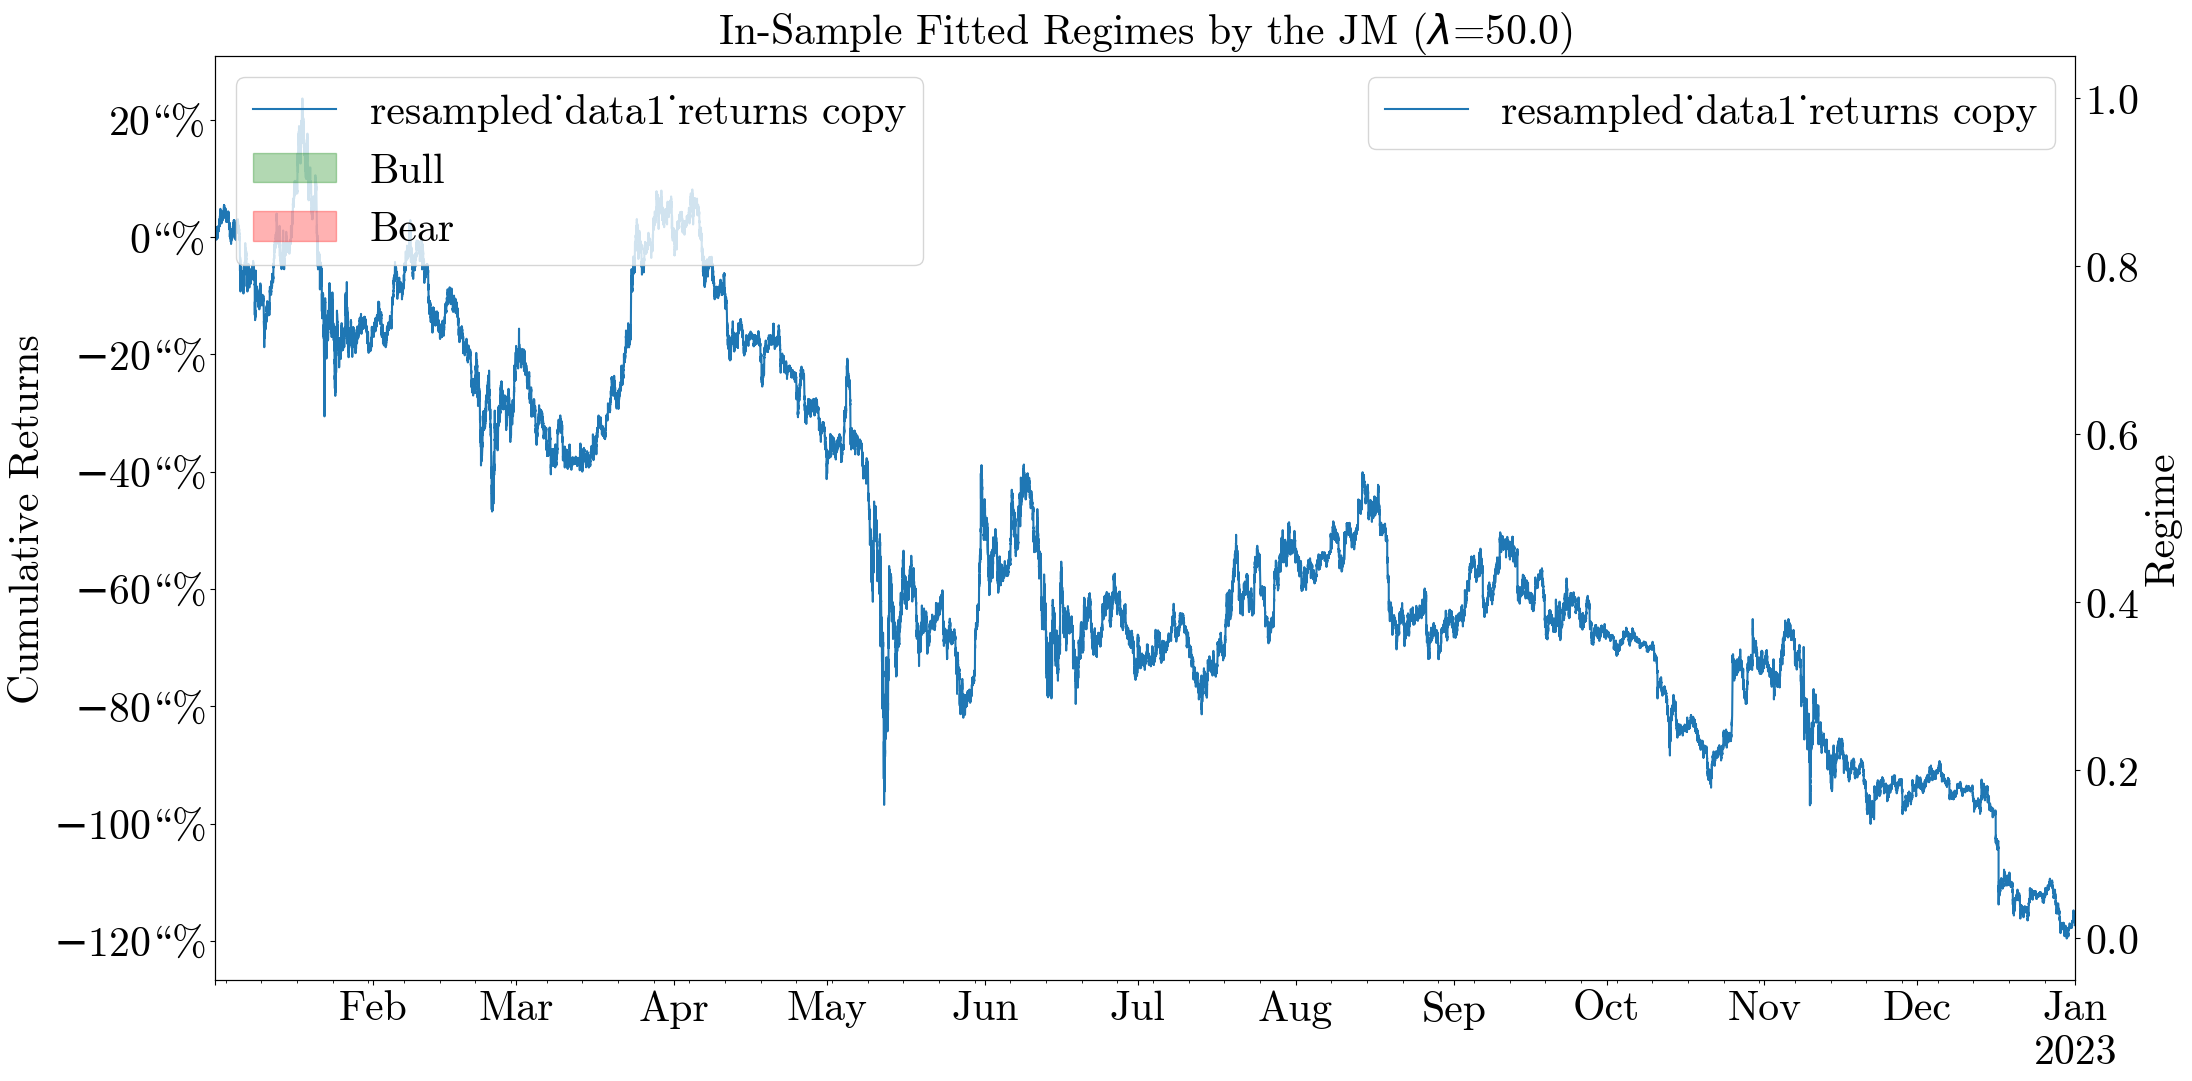

In [ ]:
from jumpmodels.jumpmodels.plot import plot_regimes_and_cumret, savefig_plt
import matplotlib as mpl

# Disable external LaTeX rendering, use built-in mathtext:
mpl.rcParams['text.usetex'] = False

ax, ax2 = plot_regimes_and_cumret(jm.labels_, data.ret_ser, n_c=2, start_date=train_start, end_date=train_end, )
ax.set(title=f"In-Sample Fitted Regimes by the JM ($\\lambda$={jump_penalty})")
# savefig_plt(f"{get_curr_dir()}/plots/JM_lambd-{jump_penalty}_train.pdf")

In [ ]:
scaler = PowerTransformer(method='yeo-johnson', standardize=True)
data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])

scaler = MinMaxScaler(feature_range=(-1, 1))
train_matrix = scaler.fit_transform(data_scaled)

train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)

In [ ]:
train_matrix1_np = train_matrix1.numpy()
index = np.arange(100)

In [ ]:
# set the jump penalty
jump_penalty=3
# initlalize the JM instance
jm = JumpModel(n_components=2, jump_penalty=jump_penalty, cont=False, )
# call .fit()
jm.fit(train_matrix1, sort_by="cumret")

JumpModel(jump_penalty=3)

In [ ]:
jm.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], dtype=int64)

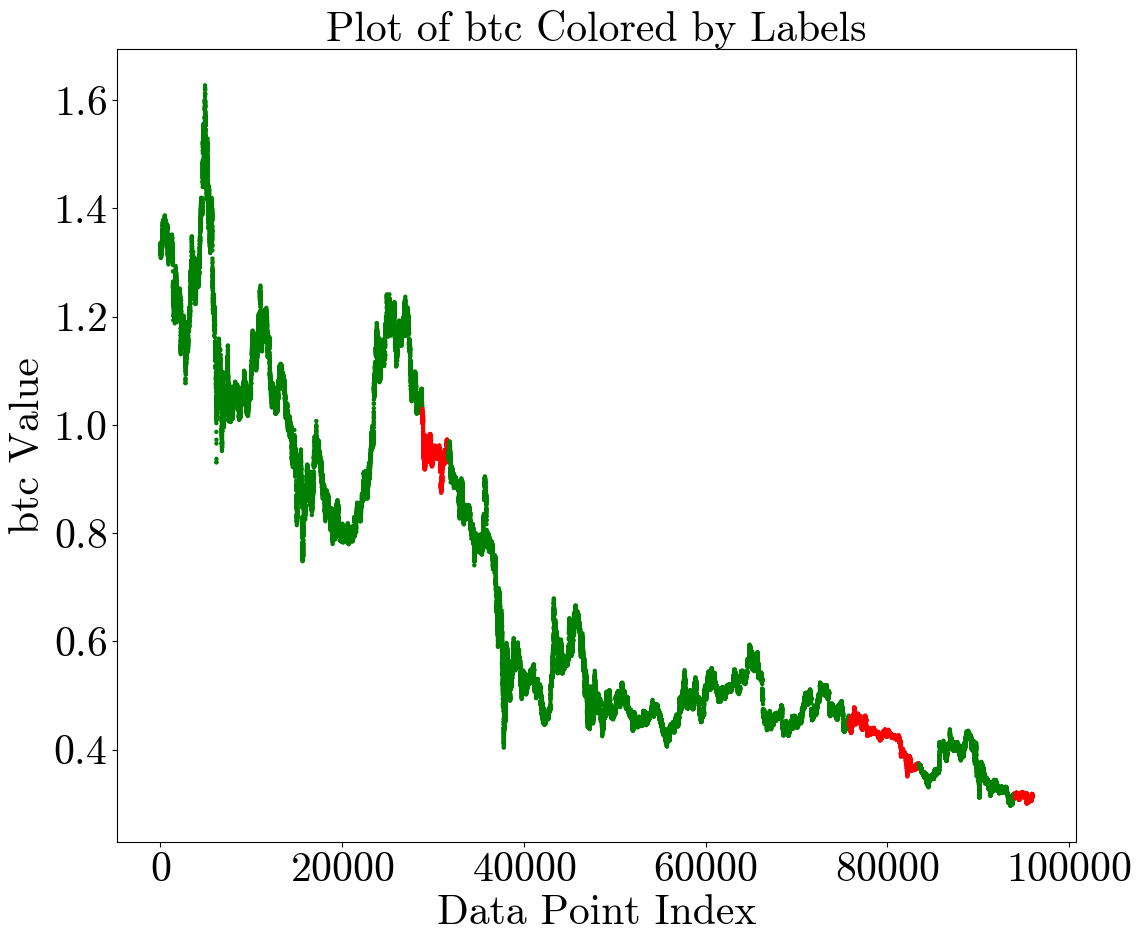

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


initial_preds_rep = np.repeat(jm.labels_.flatten(), 10*96)

# # Assuming initial_preds_rep is already defined and repeated correctly
# initial_preds_rep = np.repeat(inital_preds2.cpu(), 10*96)

resampled_data1
# Assuming eth and btc data are already extracted
btc = resampled_data1.values[:96000, 0]


# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs.scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs.set_title('Plot of btc Colored by Labels')
axs.set_xlabel('Data Point Index')
axs.set_ylabel('btc Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


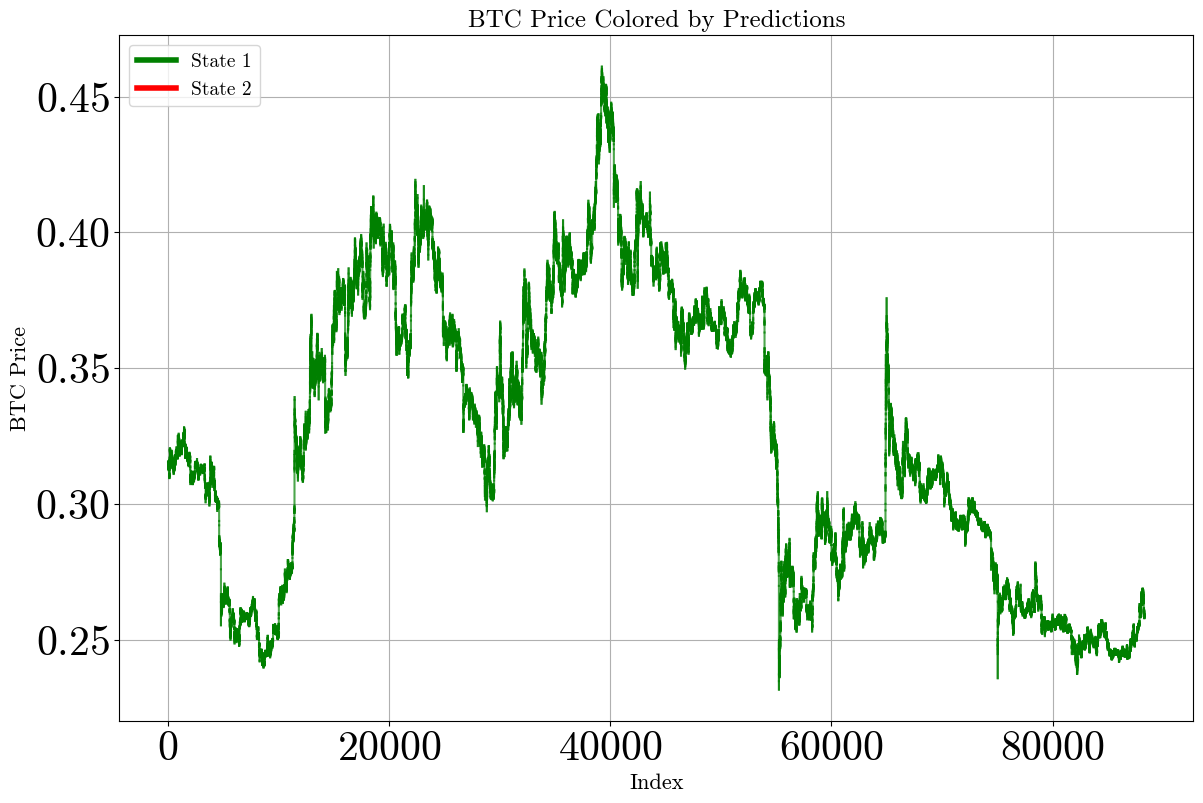

In [ ]:
import SIGSOM.sigsom.utils.helpers2 as helper_functions

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
# Assuming `vif_cleaned_result`, scalers, and gsomm are defined elsewhere in the code
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
labels_test = jm.predict(test_matrix)
test_preds = labels_test.flatten()
initial_preds_rep = np.repeat(test_preds, 10*96)
initial_preds_rep.shape

# Assuming btc data is already extracted
btc = resampled_data1.values[96000:, 0]
output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\bitcoin.png"

helper_functions.plot_btc_price(predictions=initial_preds_rep, btc_prices=btc, output_path=output_path, title='BTC Price Colored by Predictions')

### SOM Jump

In [9]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
import numpy as np
from SIGSOM.sigsom.som.som_jump import SOM  # Import the new SOM with Jump Penalty
# from SIGSOM.sigsom.som.som import SOM  # Import the new SOM with Jump Penalty

from datetime import datetime

# Initialize variables for tracking the best model
best_som = None
lowest_quantization_error = float('inf')

# Perform the process multiple times to find the best SOM model
for i in range(1):
    print(f"Run {i+1}/30")

    # Step 1: Preprocess the Data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100, :])  

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)
    train_matrix1 = torch.tensor(train_matrix, dtype=torch.float32)
    # params = SOMParams(map_size=(2, 1),Tmax=6,Tmin=.01,batch_size = 512,iterations = 500, input_dims=train_matrix1.shape[1], lr=0.05, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))

    # Step 2: Define SOM Parameters
    params = SOMParams(
        map_size=(2, 1),
        Tmax=2,
        Tmin=0.1,
        batch_size=512,
        iterations=500,
        input_dims=train_matrix1.shape[1],
        lr=0.05,
        jump_penalty_epochs=10,  # Every 10 epochs, apply BMU smoothing
        lambda_jump=0,  # Strength of jump penalty
        decay="exponential",
        dump_path=r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"
    )

    # Step 3: Initialize and Train the SOM with Jump Penalty
    som_model = SOM(logger=logger, params=params)
    som_model.initialize(train_matrix1)
    som_model.fit(X_train=train_matrix1)

#     # Step 4: Compute Quantization Error
#     quantization_error = som_model.compute_quantization_error(train_matrix1)

#     # Step 5: Keep track of the best model
#     if quantization_error < lowest_quantization_error:
#         lowest_quantization_error = quantization_error
#         best_som = som_model
#         print(f"New best model found with quantization error: {quantization_error.item()}")

# # Final Output
# print(f"Lowest quantization error: {lowest_quantization_error.item()}")


Run 1/30


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

2025-02-24 11:55:48,536        som_jump INFO     MainThread   MainProcess Using jump penalty with 10 iterations
2025-02-24 11:55:48,557        som_jump INFO     MainThread   MainProcess Applying BMU smoothing at epoch 10
2025-02-24 11:55:48,563        som_jump INFO     MainThread   MainProcess Smoothed BMU sequence computed.
2025-02-24 11:55:48,587        som_jump INFO     MainThread   MainProcess Applying BMU smoothing at epoch 20
2025-02-24 11:55:48,601        som_jump

Training with jump penalty completed.


In [ ]:
som_model.predict(train_matrix1)

tensor([1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        1, 0, 0, 0])

In [11]:
som_model.refine_bmu_sequence(a, train_matrix1,lambda_jump=0.4)

tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
        1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 1, 1, 1])

In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = som_model.predict(train_matrix1)
a = som_model.refine_bmu_sequence(a, train_matrix1,lambda_jump=0.3)
initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)

# # Assuming initial_preds_rep is already defined and repeated correctly
# initial_preds_rep = np.repeat(inital_preds2.cpu(), 10*96)



In [13]:
a = som_model.predict(train_matrix1)
a = som_model.refine_bmu_sequence(a, train_matrix1,lambda_jump=0.3)
initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)

In [16]:
btc.shape

(89018,)

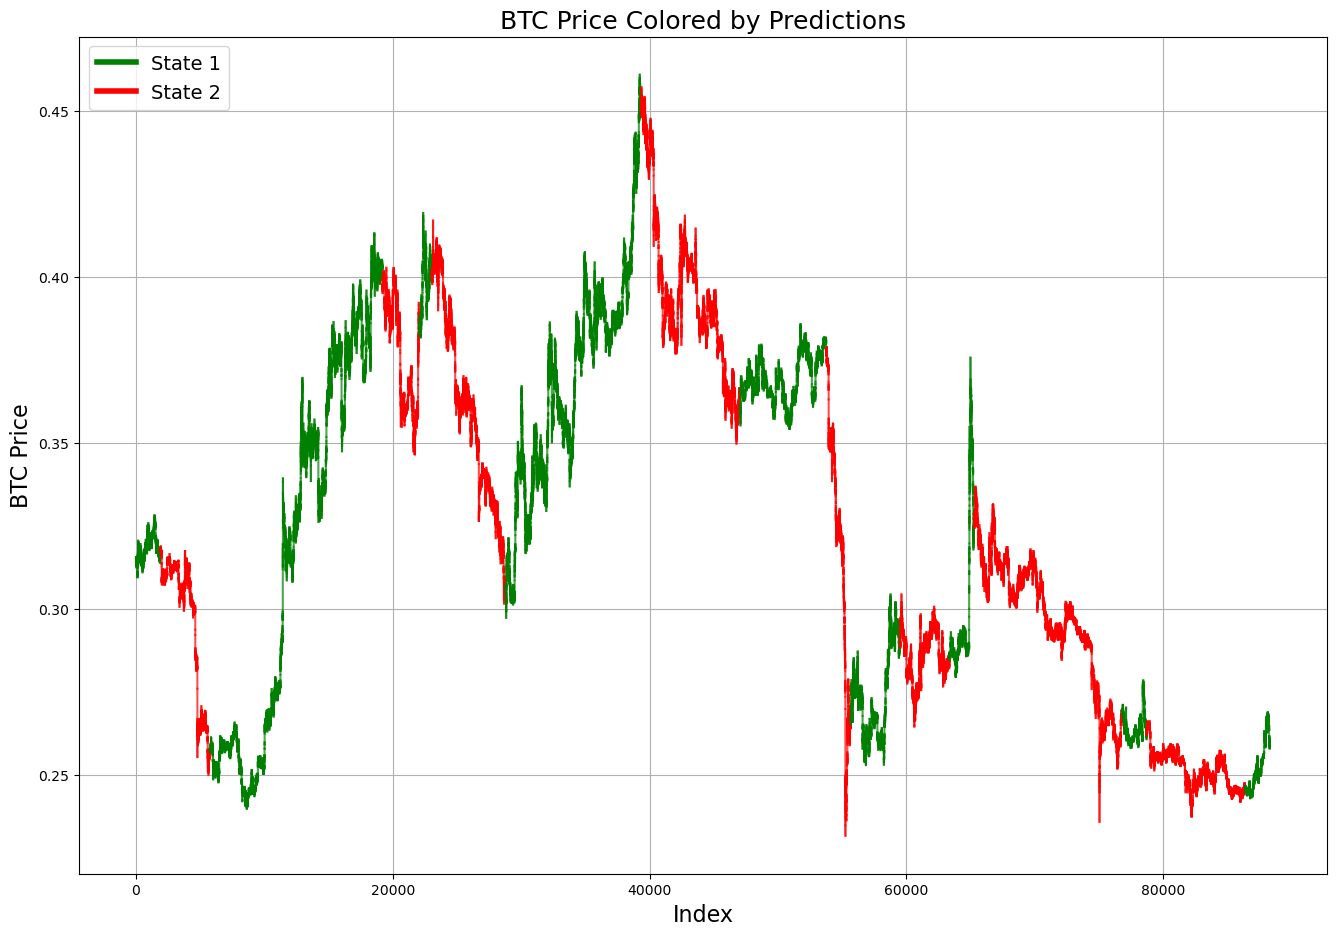

In [14]:
import SIGSOM.sigsom.utils.helpers2 as helper_functions

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
# Assuming `vif_cleaned_result`, scalers, and gsomm are defined elsewhere in the code
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
b = som_model.predict(test_matrix)  # Replace 'gsomm.predict' with your method
b = som_model.refine_bmu_sequence(b, test_matrix,lambda_jump=0.2)
test_preds = np.array(b).flatten()
initial_preds_rep = np.repeat(test_preds, 10*96)
initial_preds_rep.shape

# Assuming btc data is already extracted
btc = resampled_data1.values[96000:, 0]
output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\bitcoin_jump.png"

helper_functions.plot_btc_price(predictions=initial_preds_rep, btc_prices=btc, output_path=output_path, title='BTC Price Colored by Predictions')